In [ ]:
#load libraries and snapshot
import numpy as np
import h5py as h5
import os
import matplotlib.pyplot as plt
import matplotlib as mpl

libpath = "/beegfs/general/skoudmani/students/kasar/python/vortrace.libs"

os.environ["LD_LIBRARY_PATH"] = (
    libpath + ":" + os.environ.get("LD_LIBRARY_PATH", "")) #Adds the vortrace.libs directory to the Linux shared-library search path.
#This allows Python to find required .so files when importing vortrace

import sys
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/') #adds a custom directory to python's module search path
import vortrace as vt #vortrace performs Voronoi-based projections/interpolations for AREPO data.

# Load an Arepo snapshot q = 1
f = h5.File("/beegfs/general/kprofit/binary_tests/al_td_96/snapshot_000.hdf5", "r") #opens Arepo snapshot
pos = np.array(f["PartType0/Coordinates"]) #load gas cell positions
rho = np.array(f["PartType0/Density"]) #load gas desnities
mass = np.array(f["PartType0/Masses"]) #load gas cell masses
vol = mass / rho #calculate gas volume from mas and density
BoxSize = f["Parameters"].attrs["BoxSize"] #reads simulation box size from snapshot metadata
f.close()

# Load an Arepo snapshot q=3
f = h5.File("/beegfs/general/skoudmani/binary_proj/adios_runs/production_binary/misal_td/snapshot_000.hdf5", "r")
pos1 = np.array(f["PartType0/Coordinates"])
rho1 = np.array(f["PartType0/Density"])
mass1 = np.array(f["PartType0/Masses"])
vol1 = mass1 / rho1
BoxSize = f["Parameters"].attrs["BoxSize"]
f.close()

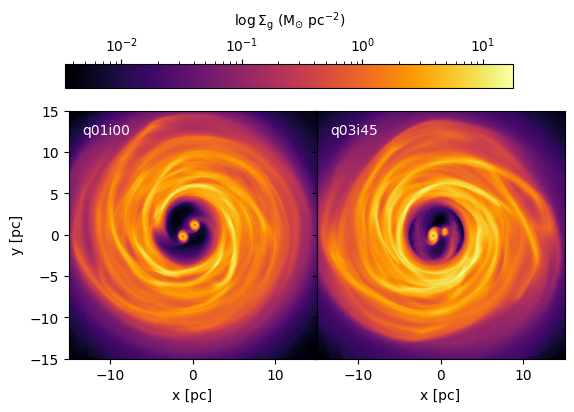

In [3]:
#Create projection and plot result
# Create a projection cloud
pc = vt.ProjectionCloud(
    pos, rho, vol=vol,
    boundbox=[0, BoxSize, 0, BoxSize, 0, BoxSize], #box = [xmin, xmax, ymin, ...]
) #constructs a voronoi projection object from position, density, volume and boxsixe

pc1 = vt.ProjectionCloud(
    pos1, rho1, vol=vol1,
    boundbox=[0, BoxSize, 0, BoxSize, 0, BoxSize],
)

# Make a grid projection
L = 30.0 #projected image width (square region - length x width)
extent = [BoxSize / 2 - L / 2, BoxSize / 2 + L / 2] #defines x/y region to project
bounds = [0, BoxSize] #z projection depth
npix = 512 # resolution (num of pixels x num of pixels)

image0 = pc.grid_projection(extent, npix, bounds, center=None) # computes projected image
image1 = pc1.grid_projection(extent, npix, bounds, center=None) # computes projected image

vmin = min(np.nanmin(image0), np.nanmin(image1))
vmax = max(np.nanmax(image0), np.nanmax(image1))

# Plot the result
#fig, ax, im = vt.plot.plot_grid(
#    image,
#    extent=[-L / 2, L / 2, -L / 2, L / 2], #plots L/2 box
#    label=r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$"
#)

#fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

#_, _, im0 = vt.plot.plot_grid(image0, extent=[-L/2, L/2, -L/2, L/2], ax=ax[0])
#_, _, im1 = vt.plot.plot_grid(image1, extent=[-L/2, L/2, -L/2, L/2],ax=ax[1])

#cbar = fig.colorbar(im1, ax=ax, orientation='horizontal', location='top', pad=0.05)

fig, ax = plt.subplots(1, 2, sharey=True,gridspec_kw={'wspace': 0})

#fig.subplots_adjust() #leave room at the top
# Add colorbar axis
cax = fig.add_axes([0.12, 0.8, 0.7, 0.05])

# First panel
_, _, im0 = vt.plot.plot_grid(image0, extent=[-L/2, L/2, -L/2, L/2], ax=ax[0], colorbar=False, label=None)

# Second panel
_, _, im1 = vt.plot.plot_grid(image1, extent=[-L/2, L/2, -L/2, L/2], ax=ax[1], colorbar=False, label=None)

#ax[0].set_title("Snapshot 000")
#ax[1].set_title("Snapshot 100")

ax[0].set_xlabel("x [pc]")
ax[0].set_ylabel("y [pc]")
ax[1].set_xlabel("x [pc]")


# Shared colorbar above both panels
cbar = fig.colorbar(im0, cax=cax, orientation='horizontal', fraction=0.2, pad=0.09)
cbar.ax.xaxis.set_label_position('top')
cbar.set_label(r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$", labelpad=8)
cbar.ax.xaxis.set_ticks_position('top')

ax[0].text(0.15, 0.92, 'q01i00', color="white", horizontalalignment='center', verticalalignment='center', transform=ax[0].transAxes)
ax[1].text(0.15, 0.92, 'q03i45', color="white", horizontalalignment='center', verticalalignment='center', transform=ax[1].transAxes)

# Remove the overlapping -15 tick mark from the right subplot
#ticks = ax[1].get_xticks()
#if len(ticks) > 0:
    # Filter out the leftmost tick value (-15)
 #   ax[1].set_xticks([t for t in ticks if t > -15])


#plt.tight_layout()
plt.savefig("Voronoi_bin_projection_comparison.png",dpi=300,bbox_inches='tight')

#cbar.set_label(r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$")

#ax.set_xlabel("x [pc]")
#ax.set_ylabel("y [pc]")
#fig.savefig("Voronoi_bin_projection.png", dpi=300, bbox_inches='tight')

In [26]:
import os
print(os.getcwd())

print(extent)

/beegfs/general/kprofit/analysis_scripts
[35.0, 65.0]


In [20]:
help(vt.plot.plot_grid)

Help on function plot_grid in module vortrace.plot:

plot_grid(data: 'ArrayLike', *, extent: 'ArrayLike | None' = None, ax: 'Any' = None, log: 'bool' = True, cmap: 'str' = 'inferno', colorbar: 'bool' = True, label: 'str | None' = None, **imshow_kwargs: 'Any') -> 'tuple[Any, Any, Any]'
    Display a 2-D projection grid as an image.
    
    Parameters
    ----------
    data : array_like
        2-D projection array (will be transposed for display so that the
        first axis corresponds to *x* and the second to *y*).
    extent : array_like, optional
        ``[xmin, xmax, ymin, ymax]`` passed to ``imshow``.
    ax : matplotlib Axes, optional
        Axes to plot into.  A new figure is created if *None*.
    log : bool
        If *True* (default), use ``LogNorm``.
    cmap : str
        Colormap name (default ``"inferno"``).
    colorbar : bool
        Whether to add a colorbar.
    label : str, optional
        Colorbar label.
    **imshow_kwargs
        Extra keyword arguments forw